# F1 Overcut Strategy Prediction
---
**Research Question:** Given the state of a battle at the moment the **car directly ahead** pits, can I predict whether the car behind, by **staying out** on older tyres, will still come out ahead after both drivers have stopped?

**Approach:**
- **Label:** Overcut success = the stay-out driver is ahead of the formerly-ahead car 4 laps after the stay-out driver's own pit stop.
- **Decision point:** the lap *before* the car ahead pits (`dec_lap = pit_lap − 1`), so the features are not contaminated by the in-lap itself.
- **Exclusions:** any attempt where a Safety Car or VSC appears between the two pit stops is dropped, because at that point the outcome is no longer a clean strategy decision.
- **Temporal split:** train 2022–2023, test 2024. I kept this identical to the undercut model so the two can be compared directly.

**Pipeline:** the dataset and model were built by `scripts/build_overcut_dataset.py` and cached in `data/f1_overcut_dataset.csv` and `models/f1_overcut_model.pkl`. This notebook loads those artefacts and focuses on analysis: EDA, 2024 evaluation, SHAP feature attribution, and findings.

---


## 1. Setup

This section just handles the environment setup and imports so the rest of the notebook can focus on the analysis.


In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_score, recall_score, f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT        = Path.cwd() if Path.cwd().name != 'notebooks' else Path.cwd().parent
DATA_DIR    = ROOT / 'data'
MODEL_DIR   = ROOT / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_YEARS = [2022, 2023]
TEST_YEARS  = [2024]


## 2. Load Pre-Built Dataset and Model

The dataset was built by `scripts/build_overcut_dataset.py` across 2022 to 2024 and saved to `data/f1_overcut_dataset.csv`. The XGBoost model was trained on 2022–23, with the 2024 holdout kept separate the whole time.


In [2]:
df       = pd.read_csv(DATA_DIR / 'f1_overcut_dataset.csv')
artefact = joblib.load(MODEL_DIR / 'f1_overcut_model.pkl')
xgb_model = artefact['model']
FEATURES  = artefact['features']

print(f'Overcut dataset: {df.shape[0]:,} labelled attempts × {df.shape[1]} cols')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Overall success rate: {df["overcut_success"].mean():.1%}')
print(f'\nPer-year split:')
print(df.groupby("year")["overcut_success"].agg(["count", "mean"]).round(3).to_string())


Overcut dataset: 932 labelled attempts × 21 cols
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Overall success rate: 25.1%

Per-year split:
      count   mean
year              
2022    269  0.283
2023    324  0.256
2024    339  0.221


## 3. Feature Engineering

Here I one-hot encode compound, drop rows missing any of the required core features, and median-impute any remaining gaps. So the point is to keep the notebook aligned with the build script, which means the model sees the same feature layout it was trained on.


In [3]:
# Mirror the feature engineering from the build script
compound_dummies = pd.get_dummies(df['compound'], prefix='compound')
df_feat = pd.concat([df, compound_dummies], axis=1)

REQUIRED = ['gap_ahead', 'tire_age', 'ca_tire_age', 'own_pace', 'threat_pace']
df_model = df_feat.dropna(subset=REQUIRED + ['overcut_success']).copy()

for col in FEATURES:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())
    else:
        df_model[col] = 0

print(f'Modelling dataset: {len(df_model):,} samples, {len(FEATURES)} features')
print(f'Class balance: {df_model["overcut_success"].mean():.1%} successful overcuts')


Modelling dataset: 931 samples, 18 features
Class balance: 25.0% successful overcuts


## 4. Exploratory Data Analysis

### 4.1 Gap to car ahead vs overcut success

The basic intuition check here is simple. The strategy should be riskier when the stay-out driver is further behind, because there is less margin to absorb the pace loss on older rubber.


Success rate by gap to (now-pitting) car ahead at decision point:
          success_rate  n_attempts
gap_bin                           
(0, 2]           0.340         453
(2, 4]           0.199         181
(4, 6]           0.228         114
(6, 8]           0.091          55
(8, 12]          0.103          58
(12, 20]         0.103          58
(20, 30]         0.000          12


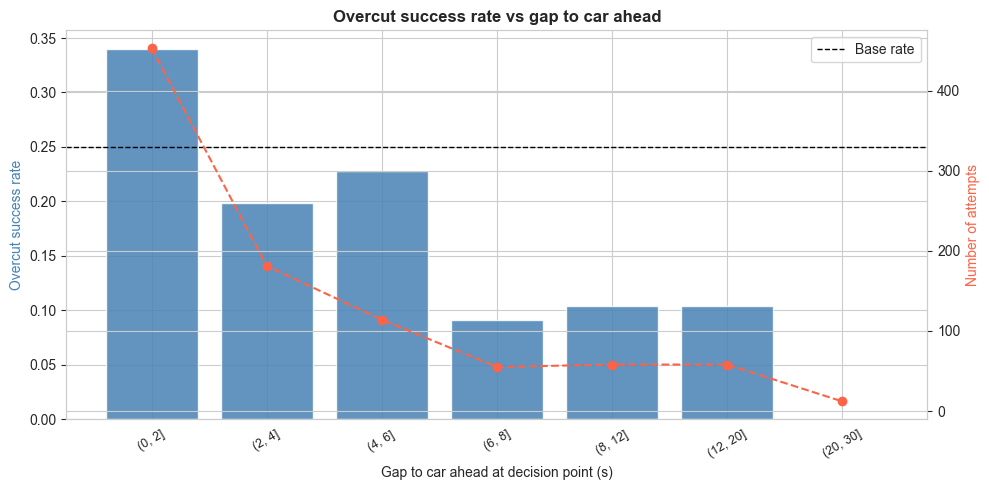

In [4]:
df_model['gap_bin'] = pd.cut(df_model['gap_ahead'], bins=[0, 2, 4, 6, 8, 12, 20, 30])
gap_success = df_model.groupby('gap_bin', observed=True)['overcut_success'].agg(['mean', 'count'])
gap_success.columns = ['success_rate', 'n_attempts']
print('Success rate by gap to (now-pitting) car ahead at decision point:')
print(gap_success.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(gap_success)), gap_success['success_rate'], color='steelblue', alpha=0.85)
ax2.plot(range(len(gap_success)), gap_success['n_attempts'], 'o--', color='tomato')
ax1.axhline(df_model['overcut_success'].mean(), color='black', linestyle='--',
            linewidth=1, label='Base rate')
ax1.set_xticks(range(len(gap_success)))
ax1.set_xticklabels([str(b) for b in gap_success.index], rotation=30, fontsize=9)
ax1.set_xlabel('Gap to car ahead at decision point (s)')
ax1.set_ylabel('Overcut success rate', color='steelblue')
ax2.set_ylabel('Number of attempts', color='tomato')
ax1.set_title('Overcut success rate vs gap to car ahead', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_gap_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Tire-age delta vs success

`tire_age_delta` is the stay-out driver's tyre age minus the now-pitted car's age at the decision point. Positive values mean the stay-out car is already on much older rubber, so the physical disadvantage gets worse with every extra lap they try to extend.


Success rate by tire_age_delta (stay-out tire age − pitting-car tire age):
               success_rate  n_attempts
age_delta_bin                          
(-20, -10]            0.606         137
(-10, -5]             0.338          74
(-5, 0]               0.183         595
(0, 5]                0.083         108
(5, 10]               0.143           7
(10, 20]              0.000           1


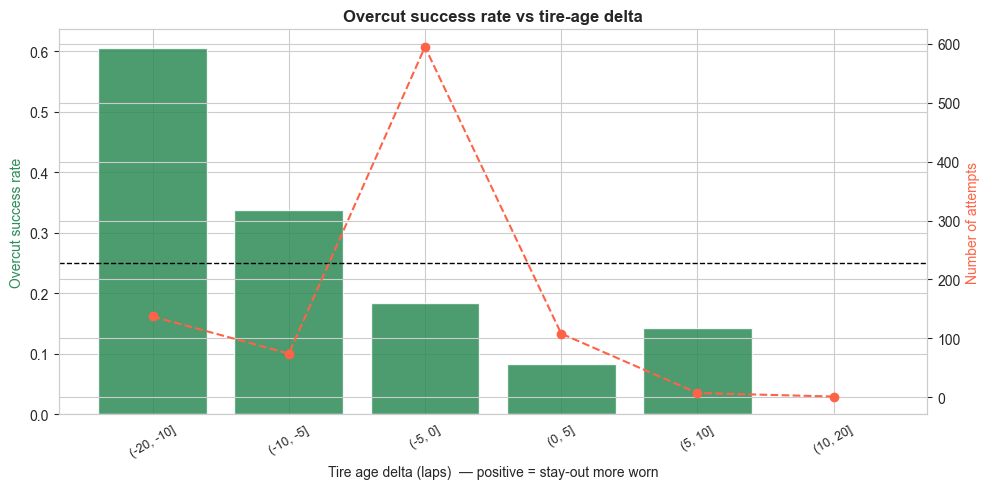

In [5]:
df_model['age_delta_bin'] = pd.cut(
    df_model['tire_age_delta'],
    bins=[-20, -10, -5, 0, 5, 10, 20, 40]
)
age_success = df_model.groupby('age_delta_bin', observed=True)['overcut_success'].agg(['mean', 'count'])
age_success.columns = ['success_rate', 'n_attempts']
print('Success rate by tire_age_delta (stay-out tire age − pitting-car tire age):')
print(age_success.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(len(age_success)), age_success['success_rate'], color='seagreen', alpha=0.85)
ax2.plot(range(len(age_success)), age_success['n_attempts'], 'o--', color='tomato')
ax1.axhline(df_model['overcut_success'].mean(), color='black', linestyle='--', linewidth=1)
ax1.set_xticks(range(len(age_success)))
ax1.set_xticklabels([str(b) for b in age_success.index], rotation=30, fontsize=9)
ax1.set_xlabel('Tire age delta (laps)  — positive = stay-out more worn')
ax1.set_ylabel('Overcut success rate', color='seagreen')
ax2.set_ylabel('Number of attempts', color='tomato')
ax1.set_title('Overcut success rate vs tire-age delta', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_age_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Feature distributions split by outcome

Overlaying the success and failure distributions for each numeric feature helps me see where the two outcomes separate cleanly and where they still overlap a lot. So this is basically a quick read on which variables look genuinely predictive before I lean on the model output.


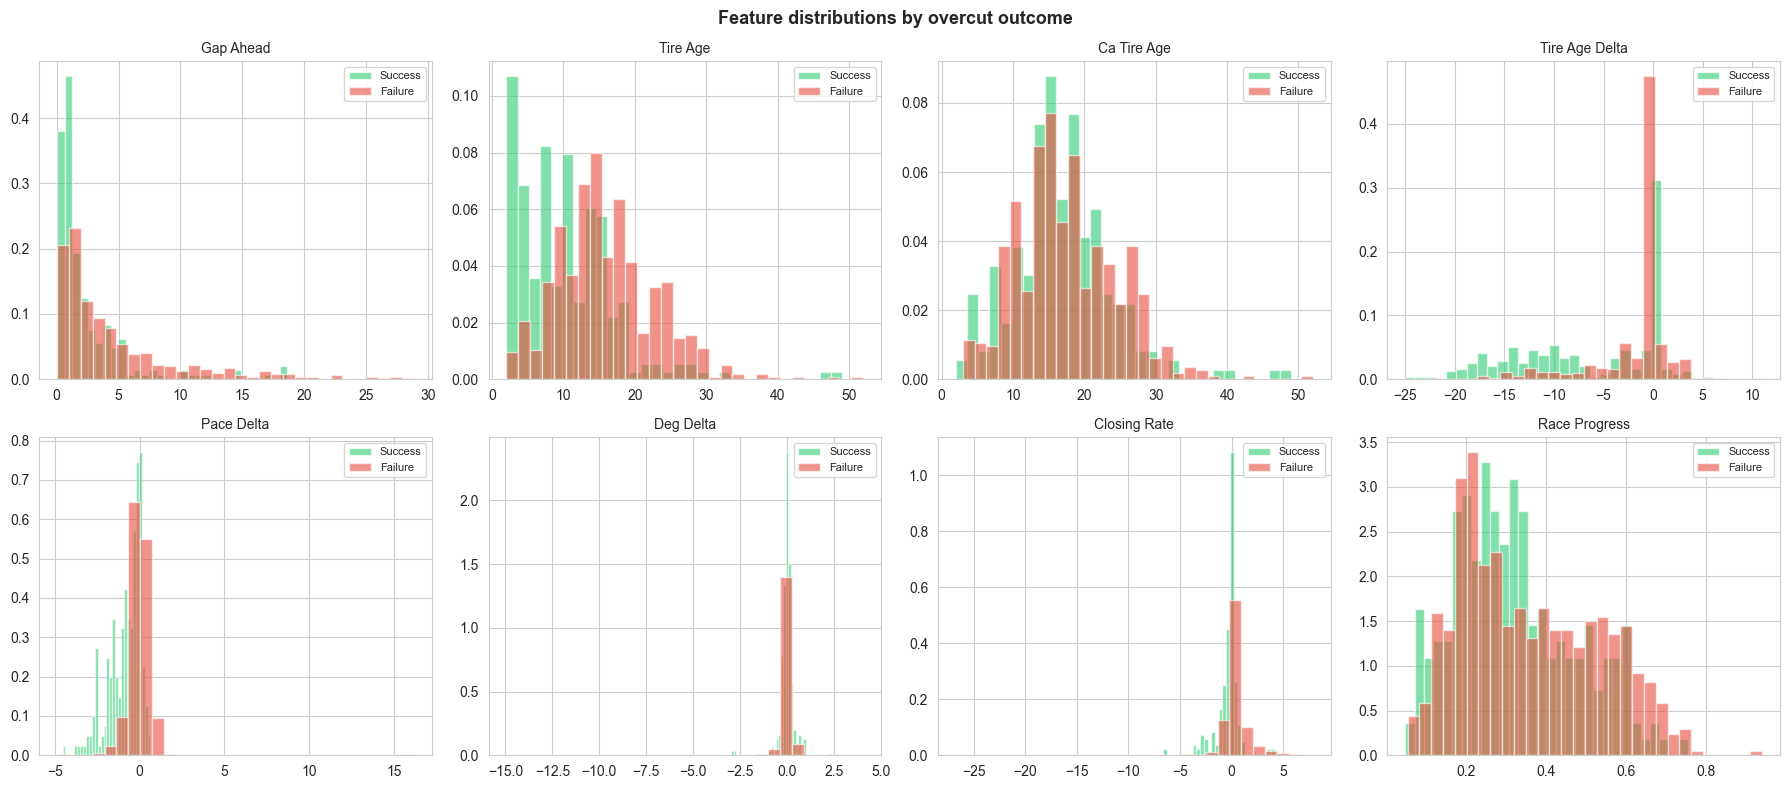

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
eda_feats = ['gap_ahead', 'tire_age', 'ca_tire_age', 'tire_age_delta',
             'pace_delta', 'deg_delta', 'closing_rate', 'race_progress']
colours = {1: '#2ecc71', 0: '#e74c3c'}
for ax, feat in zip(axes, eda_feats):
    for label, name in {1: 'Success', 0: 'Failure'}.items():
        subset = df_model[df_model['overcut_success'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=colours[label], label=name, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Feature distributions by overcut outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Train / Test Split (Temporal)

2022–23 goes to train, and 2024 is held out for test. I kept this exactly matched to the undercut pipeline so the comparison stays fair.


In [7]:
train_mask = df_model['year'].isin(TRAIN_YEARS)
test_mask  = df_model['year'].isin(TEST_YEARS)

X_train = df_model.loc[train_mask, FEATURES].values.astype(float)
y_train = df_model.loc[train_mask, 'overcut_success'].values.astype(int)
X_test  = df_model.loc[test_mask,  FEATURES].values.astype(float)
y_test  = df_model.loc[test_mask,  'overcut_success'].values.astype(int)

print(f'Train (2022-23): {len(X_train):,}  |  Test (2024): {len(X_test):,}')
print(f'Train success rate: {y_train.mean():.1%}  |  Test success rate: {y_test.mean():.1%}')


Train (2022-23): 592  |  Test (2024): 339
Train success rate: 26.7%  |  Test success rate: 22.1%


## 6. Model Evaluation, 2024 Holdout

Here I evaluate the cached XGBoost model directly, then refit a simple Logistic Regression baseline so I have an interpretable comparison point.


=== 2024 Holdout — Overcut ===
                         Model  Accuracy  ROC-AUC  Precision  Recall    F1
Logistic Regression (baseline)     0.823    0.807      0.703   0.347 0.464
             XGBoost (primary)     0.805    0.804      0.560   0.560 0.560


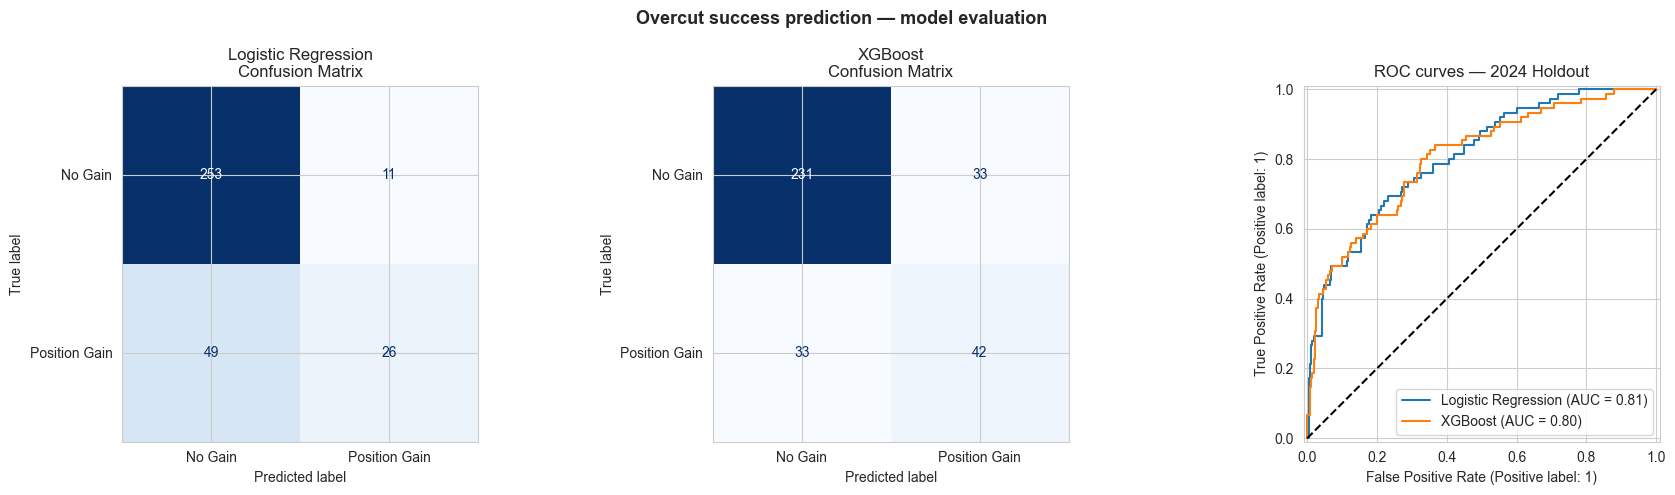

In [8]:
# The XGB model is already trained and cached — evaluate directly.
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Re-fit a Logistic Regression baseline on the same split for comparison.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=2000, C=1.0, random_state=42))])
lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict(X_test)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]

summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',
     'Accuracy':  accuracy_score(y_test, lr_preds),
     'ROC-AUC':   roc_auc_score(y_test, lr_probs),
     'Precision': precision_score(y_test, lr_preds),
     'Recall':    recall_score(y_test, lr_preds),
     'F1':        f1_score(y_test, lr_preds)},
    {'Model': 'XGBoost (primary)',
     'Accuracy':  accuracy_score(y_test, xgb_preds),
     'ROC-AUC':   roc_auc_score(y_test, xgb_probs),
     'Precision': precision_score(y_test, xgb_preds),
     'Recall':    recall_score(y_test, xgb_preds),
     'F1':        f1_score(y_test, xgb_preds)},
]).round(3)

print('=== 2024 Holdout — Overcut ===')
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds,
    display_labels=['No Gain', 'Position Gain'], ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds,
    display_labels=['No Gain', 'Position Gain'], ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost\nConfusion Matrix')
RocCurveDisplay.from_predictions(y_test, lr_probs,  ax=axes[2], name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, xgb_probs, ax=axes[2], name='XGBoost')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC curves — 2024 Holdout')
fig.suptitle('Overcut success prediction — model evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. SHAP Feature Attribution

Tree SHAP gives per-prediction feature contributions and then aggregates them into global importance. The beeswarm on the right also shows direction, with red meaning a high feature value and blue meaning a low one. So this section helps me move from "the model works" to "why the model is making these calls.


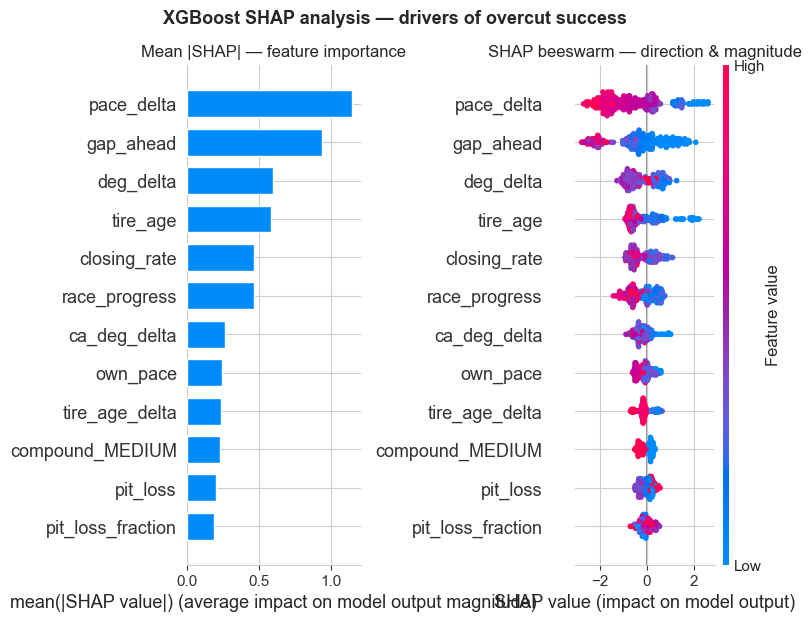

Top 8 features by mean |SHAP|:
pace_delta       1.1519
gap_ahead        0.9377
deg_delta        0.5987
tire_age         0.5887
closing_rate     0.4713
race_progress    0.4679
ca_deg_delta     0.2649
own_pace         0.2478


In [9]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  show=False, max_display=12, plot_type='bar')
axes[0].set_title('Mean |SHAP| — feature importance')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  show=False, max_display=12)
axes[1].set_title('SHAP beeswarm — direction & magnitude')
plt.suptitle('XGBoost SHAP analysis — drivers of overcut success',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'overcut_shap.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURES
).sort_values(ascending=False)
print('Top 8 features by mean |SHAP|:')
print(mean_abs_shap.head(8).round(4).to_string())


## 8. Probability Calibration

If a strategist asks, "what is the probability this overcut works?", that number only means anything if the predicted probability lines up with real observed frequency. So points close to the diagonal are what I want to see here.


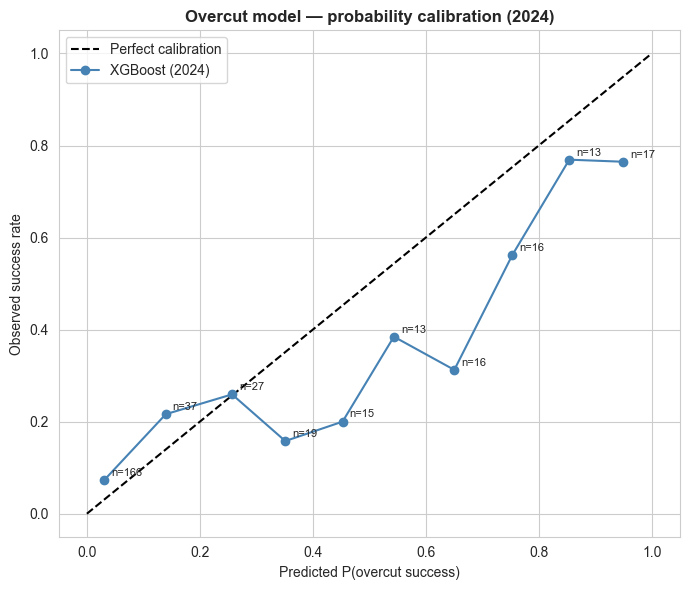

In [10]:
prob_bins = np.linspace(0, 1, 11)
bin_idx = np.clip(np.digitize(xgb_probs, prob_bins) - 1, 0, len(prob_bins) - 2)
cal = []
for b in range(len(prob_bins) - 1):
    mask = bin_idx == b
    if mask.sum() < 5: continue
    cal.append({
        'pred_mean': xgb_probs[mask].mean(),
        'actual':    y_test[mask].mean(),
        'n':         int(mask.sum()),
    })
cal_df = pd.DataFrame(cal)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(cal_df['pred_mean'], cal_df['actual'],
        'o-', color='steelblue', label='XGBoost (2024)')
for _, r in cal_df.iterrows():
    ax.annotate(f"n={int(r['n'])}",
                (r['pred_mean'], r['actual']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Predicted P(overcut success)')
ax.set_ylabel('Observed success rate')
ax.set_title('Overcut model — probability calibration (2024)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Key Findings

**Base rate.** Overcuts are just harder than undercuts in this sample. Across 2022–24 the base-rate success was **25.1%**, compared with roughly 44% for undercuts. In 2024 specifically it dropped to 22.1%, which likely reflects the field being more compressed and the stay-out window getting smaller. So a naïve "always predict failure" baseline would already score 77.9% accuracy on the 2024 holdout. That is why I do not treat accuracy as the main headline here. **ROC-AUC and F1 on the minority class** matter more.

**Predictive accuracy (2024 holdout).**
| Model | Accuracy | ROC-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Logistic Regression | 0.823 | 0.807 | 0.703 | 0.347 | 0.464 |
| XGBoost (primary)   | 0.805 | 0.804 | 0.560 | 0.560 | 0.560 |

Logistic Regression edges out XGBoost on headline accuracy, but that mostly happens because it predicts "failure" much more often. Its recall on successes is 34.7%, while XGBoost gets to 56.0%. So the XGB model catches far more real overcut opportunities at similar precision, and that is much closer to what a useful strategy tool should do.

**Dominant features (SHAP mean |φ|).**
1. **`pace_delta`** (1.15) , the stay-out driver's clean-air pace relative to the now-pitted car. If the stay-out driver cannot go faster right after the car ahead pits, the overcut almost never works. This is the strongest signal by a wide margin.
2. **`gap_ahead`** (0.94) , small gaps at the decision point give the stay-out driver a realistic cushion. Large gaps, especially above about 8 seconds, push the success rate down toward 10%.
3. **`deg_delta`** (0.60) , this captures how fast the stay-out driver's own tyres are degrading. If the degradation slope is flat, the overcut still has a chance. If the tyres are about to fall off, it usually dies there.
4. **`tire_age`** (0.59) , the absolute tyre age of the stay-out driver matters too. Very old tyres usually cannot hold the pace needed to make the strategy work.

**Interpretation.** The big takeaway for me is that the overcut is much more pace-sensitive than the undercut. With the undercut, fresh-tire gain does a lot of the work for you. With the overcut, the driver has to actively produce strong laps on older tyres before stopping. So the model is not just learning that overcuts are rare. It is learning the specific conditions where staying out is still worth trying.
